# Predição de Sobrevivente: Spaceship Titanic

Este notebook concentra a parte de modelagem do projeto. A análise exploratória completa fica em `notebooks/eda.ipynb`; aqui usamos as conclusões dela para preparar os dados, treinar modelos e comparar os experimentos.

A nomenclatura dos experimentos será:
- **Caminho A**: Árvore de Decisão.
- **Caminho B**: Floresta Aleatória.
- **Caminho C**: Naive Bayes Gaussiano.

Cada experimento salva os mesmos tipos de artefatos: modelo treinado em `models/`, histórico e métricas em `reports/`, e dados/figura da curva ROC em `reports/figures/`.


## Setup do ambiente

Nesta etapa carregamos as bibliotecas, localizamos a raiz do projeto por meio de `src.roots` e criamos os diretórios de artefatos. Usar um módulo central para caminhos evita misturar diretórios do projeto com a nomenclatura dos experimentos Caminho A, Caminho B e próximos caminhos.


In [1]:
# Bibliotecas padrão
from datetime import datetime
from pathlib import Path
import sys
from time import perf_counter
import json

# Manipulação de dados e visualização
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Persistência dos modelos treinados
from joblib import dump

# Pré-processamento, pipelines e modelos
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
import optuna

# Estilo consistente para tabelas e gráficos do notebook.
sns.set_theme(style="whitegrid")

# Permite executar o notebook a partir da raiz do projeto ou da pasta notebooks/.
PROJECT_ROOT_HINT = Path.cwd()
if not (PROJECT_ROOT_HINT / "src").exists():
    PROJECT_ROOT_HINT = PROJECT_ROOT_HINT.parent

if str(PROJECT_ROOT_HINT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT_HINT))

from src.roots import (  # noqa: E402
    FIGURES_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    TEST_DATA_PATH,
    TRAIN_DATA_PATH,
    create_required_directories,
)

create_required_directories()

print(f"Treino: {TRAIN_DATA_PATH}")
print(f"Teste: {TEST_DATA_PATH}")
print(f"Modelos serão salvos em: {MODELS_DIR}")
print(f"Relatórios serão salvos em: {REPORTS_DIR}")


Treino: /home/gabrafo/Projetos/MineracaoDeDados/data/train.csv
Teste: /home/gabrafo/Projetos/MineracaoDeDados/data/test.csv
Modelos serão salvos em: /home/gabrafo/Projetos/MineracaoDeDados/models
Relatórios serão salvos em: /home/gabrafo/Projetos/MineracaoDeDados/reports


A próxima célula carrega os arquivos de treino e teste. O conjunto de treino contém a variável alvo `Transported`; o conjunto de teste não possui rótulos e fica disponível para inferências futuras com os modelos salvos.


In [2]:
# Carrega os dados brutos exatamente como foram fornecidos na competição.
train = pd.read_csv(TRAIN_DATA_PATH)
test = pd.read_csv(TEST_DATA_PATH)

target = "Transported"

print("Dimensões dos dados carregados")
display(
    pd.DataFrame(
        {
            "dataset": ["train", "test"],
            "linhas": [train.shape[0], test.shape[0]],
            "colunas": [train.shape[1], test.shape[1]],
        }
    )
)

print("Primeiras linhas do conjunto de treino")
display(train.head())


Dimensões dos dados carregados


,dataset,linhas,colunas
0,train,8693,14
1,test,4277,13


Primeiras linhas do conjunto de treino


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Pré-processamento

O pré-processamento transforma os dados brutos em uma matriz numérica adequada para os modelos. Essa etapa é importante porque a base mistura identificadores compostos, atributos categóricos, valores ausentes, variáveis booleanas e gastos monetários.

Vamos criar uma única pipeline de pré-processamento e reutilizá-la dentro das pipelines de cada experimento. Assim, Caminho A e Caminho B recebem exatamente as mesmas entradas transformadas, e a comparação entre os modelos fica mais justa.


A próxima célula separa `X` e `y`. Mantemos `X` ainda no formato bruto porque a engenharia de atributos fará parte da pipeline do scikit-learn. Isso garante que as transformações sejam ajustadas apenas nos folds de treino durante a validação cruzada, reduzindo risco de vazamento de dados.


In [3]:
# X preserva as colunas originais; a pipeline será responsável por derivar e descartar colunas.
X = train.drop(columns=[target])
y = train[target].astype(int)

print("Distribuição da variável alvo")
display(
    y.value_counts(normalize=True)
    .rename_axis("Transported")
    .reset_index(name="proporcao")
    .assign(proporcao=lambda df: df["proporcao"].round(4))
)


Distribuição da variável alvo


,Transported,proporcao
0,1,0.5036
1,0,0.4964


### Engenharia de atributos base

A EDA indicou que algumas colunas precisam ser abertas antes da modelagem:
- `PassengerId` contém o grupo de viagem e o número do passageiro dentro do grupo.
- `Cabin` contém convés, número e lado da cabine.
- `Name` permite extrair o sobrenome, útil para imputar `HomePlanet`.
- As cinco colunas de gastos continuam no modelo; o agregado `TotalSpend` será criado depois da imputação dos gastos individuais.

A próxima célula cria um transformador do scikit-learn para aplicar essas regras do mesmo modo em treino, validação, teste e inferências futuras.


In [4]:
# Colunas de gastos usadas para criar TotalSpend no pré-processamento de modelagem.
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]


class SpaceshipFeatureBuilder(BaseEstimator, TransformerMixin):
    """Cria atributos derivados a partir das colunas compostas do Spaceship Titanic."""

    def fit(self, X, y=None):
        return self

    def _split_column(self, series, separator, expected_parts):
        # str.split preserva np.nan e evita o pd.NA do dtype string, que causa erro no SimpleImputer.
        parts = series.str.split(separator, expand=True)
        for col_idx in range(expected_parts):
            if col_idx not in parts.columns:
                parts[col_idx] = np.nan
        return parts

    def transform(self, X):
        out = X.copy()

        # PassengerId tem formato gggg_pp: grupo de viagem e número no grupo.
        if "PassengerId" in out.columns:
            passenger_parts = self._split_column(out["PassengerId"], "_", expected_parts=2)
            out["PassengerGroup"] = passenger_parts[0]
            out["PassengerNum"] = pd.to_numeric(passenger_parts[1], errors="coerce")

        # Cabin tem formato deck/num/side: convés, número e lado da cabine.
        if "Cabin" in out.columns:
            cabin_parts = self._split_column(out["Cabin"], "/", expected_parts=3)
            out["CabinDeck"] = cabin_parts[0]
            out["CabinNum"] = pd.to_numeric(cabin_parts[1], errors="coerce")
            out["CabinSide"] = cabin_parts[2]

        # O sobrenome ajuda a recuperar HomePlanet quando membros da família compartilham origem.
        if "Name" in out.columns:
            out["FamilyName"] = out["Name"].str.strip().str.rsplit(" ", n=1).str[-1]

        # Removemos identificadores brutos e componentes menos úteis; mantemos os gastos individuais.
        cols_to_drop = [
            "PassengerId",
            "Cabin",
            "Name",
            "PassengerNum",
            "CabinNum",
        ]
        out = out.drop(columns=cols_to_drop, errors="ignore")

        # Normaliza tipos categóricos para object + np.nan; isso evita o erro "boolean value of NA is ambiguous".
        categorical_like = out.select_dtypes(include=["object", "string", "category", "boolean"]).columns
        for col in categorical_like:
            out[col] = out[col].astype(object).where(out[col].notna(), np.nan)

        return out


feature_builder = SpaceshipFeatureBuilder()

feature_preview = feature_builder.fit_transform(X).head()
print("Prévia dos atributos após a engenharia base")
display(feature_preview)


Prévia dos atributos após a engenharia base


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,PassengerGroup,CabinDeck,CabinSide,FamilyName
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,B,P,Ofracculy
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,F,S,Vines
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,A,S,Susent
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,A,S,Susent
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,F,S,Santantines


### Imputação de HomePlanet por regras e moda global

`HomePlanet` tem relação com o grupo de viagem e com o sobrenome. Por isso, a primeira parte da imputação usa regras determinísticas aprendidas apenas no treino:
- se houver pessoas do mesmo `PassengerGroup` com `HomePlanet` conhecido, usamos a moda do grupo;
- se ainda faltar valor, usamos a moda do `FamilyName`.

Depois dessas regras, se algum registro continuar sem `HomePlanet`, usamos o valor mais frequente de `HomePlanet` observado no dataset de treino do fold. Essa etapa final é simples, determinística e evita introduzir uma relação ordinal artificial entre categorias como `Earth`, `Europa` e `Mars`.


In [5]:
class HomePlanetRuleImputer(BaseEstimator, TransformerMixin):
    """Preenche HomePlanet pela moda do grupo, da família e depois do dataset."""

    def __init__(self, group_col="PassengerGroup", family_col="FamilyName", target_col="HomePlanet"):
        self.group_col = group_col
        self.family_col = family_col
        self.target_col = target_col

    @staticmethod
    def _mode_or_nan(series):
        # Em caso de empate, a ordenação deixa o resultado determinístico.
        values = series.dropna()
        if values.empty:
            return np.nan
        mode_values = values.mode()
        if mode_values.empty:
            return np.nan
        return mode_values.sort_values().iloc[0]

    def fit(self, X, y=None):
        df = X.copy()

        if self.target_col in df.columns:
            self.dataset_mode_ = self._mode_or_nan(df[self.target_col])
        else:
            self.dataset_mode_ = np.nan

        if self.group_col in df.columns and self.target_col in df.columns:
            self.group_mode_ = df.groupby(self.group_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.group_mode_ = pd.Series(dtype=object)

        if self.family_col in df.columns and self.target_col in df.columns:
            self.family_mode_ = df.groupby(self.family_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.family_mode_ = pd.Series(dtype=object)

        return self

    def transform(self, X):
        df = X.copy()
        if self.target_col not in df.columns:
            return df

        homeplanet = df[self.target_col].copy()

        # Primeiro fallback: origem mais frequente dentro do mesmo grupo de viagem.
        if self.group_col in df.columns:
            group_fill = df[self.group_col].map(self.group_mode_)
            homeplanet = homeplanet.fillna(group_fill)

        # Segundo fallback: origem mais frequente para o mesmo sobrenome.
        if self.family_col in df.columns:
            family_fill = df[self.family_col].map(self.family_mode_)
            homeplanet = homeplanet.fillna(family_fill)

        # Fallback final: origem mais frequente no dataset de treino do fold.
        if pd.notna(self.dataset_mode_):
            homeplanet = homeplanet.fillna(self.dataset_mode_)

        df[self.target_col] = homeplanet.astype(object).where(homeplanet.notna(), np.nan)
        return df


### Gastos e `TotalSpend`

`TotalSpend` só deve ser criado com os cinco gastos individuais completos. Por isso, o notebook usa uma etapa dedicada:
- linhas que já têm todos os gastos recebem `TotalSpend` pela soma direta;
- linhas com algum gasto ausente têm os gastos individuais restantes imputados por `KNNImputer`;
- depois da imputação, `TotalSpend` é recalculado com base nos gastos completos que entram no modelo.


In [6]:
class SpendKNNImputerAndTotalSpend(BaseEstimator, TransformerMixin):
    """Imputa gastos individuais com KNN e cria TotalSpend sem somas parciais."""

    def __init__(self, spend_columns=None, total_col="TotalSpend", n_neighbors=5):
        self.spend_columns = spend_columns
        self.total_col = total_col
        self.n_neighbors = n_neighbors

    def _spend_frame(self, df):
        return df.reindex(columns=self.spend_columns_).apply(pd.to_numeric, errors="coerce")

    def fit(self, X, y=None):
        df = X.copy()
        self.spend_columns_ = list(self.spend_columns or [])
        self.spend_imputer_ = None

        if self.spend_columns_:
            spend_frame = self._spend_frame(df)
            self.spend_imputer_ = KNNImputer(
                n_neighbors=self.n_neighbors,
                keep_empty_features=True,
            )
            self.spend_imputer_.fit(spend_frame)

        return self

    def transform(self, X):
        df = X.copy()
        if not self.spend_columns_:
            return df

        spend_frame = self._spend_frame(df)
        complete_rows = spend_frame.notna().all(axis=1)

        if (~complete_rows).any() and self.spend_imputer_ is not None:
            imputed_values = self.spend_imputer_.transform(spend_frame)
            spend_complete = pd.DataFrame(
                imputed_values,
                columns=self.spend_columns_,
                index=df.index,
            )
        else:
            spend_complete = spend_frame

        df[self.spend_columns_] = spend_complete
        df[self.total_col] = spend_complete.sum(axis=1)
        return df


### Pipeline de pré-processamento

A próxima célula monta a pipeline compartilhada. Ela aplica a engenharia de atributos, imputa `HomePlanet`, trata os gastos antes de criar `TotalSpend`, transforma variáveis numéricas, binárias e categóricas, e entrega uma matriz pronta para o classificador.

As escolhas principais são:
- regras por grupo e família, mais moda global observada no treino, para preencher `HomePlanet`;
- `SpendKNNImputerAndTotalSpend` para imputar gastos individuais restantes e criar `TotalSpend` sem soma parcial;
- `KNNImputer` e `StandardScaler` para numéricas (`Age`, gastos individuais já imputados e `TotalSpend`);
- `OrdinalEncoder` + `KNNImputer` para binárias (`CabinSide`, `CryoSleep`, `VIP`);
- `SimpleImputer` + `OneHotEncoder` para categóricas de múltiplas classes.


In [7]:
# Colunas esperadas depois de SpaceshipFeatureBuilder e SpendKNNImputerAndTotalSpend.
numeric_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "TotalSpend"]
binary_cols = ["CabinSide", "CryoSleep", "VIP"]
categorical_ohe = ["CabinDeck", "Destination", "HomePlanet", "PassengerGroup", "FamilyName"]


def round_binary(values):
    """Arredonda saídas do KNN para os códigos binários 0/1."""
    return np.clip(np.rint(values), 0, 1).astype(int)


numeric_pipeline = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler()),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OrdinalEncoder(
                categories=[["P", "S"], [False, True], [False, True]],
                handle_unknown="use_encoded_value",
                unknown_value=np.nan,
            ),
        ),
        ("imputer", KNNImputer(n_neighbors=5)),
        ("rounder", FunctionTransformer(round_binary, feature_names_out="one-to-one")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("bin", binary_pipeline, binary_cols),
        ("cat", categorical_pipeline, categorical_ohe),
    ],
    remainder="drop",
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        ("homeplanet_rules", HomePlanetRuleImputer()),
        (
            "spend_total",
            SpendKNNImputerAndTotalSpend(
                spend_columns=spend_cols,
                n_neighbors=5,
            ),
        ),
        ("columns", column_preprocessor),
    ]
)

print("Pipeline de pré-processamento compartilhada")
preprocessing_pipeline


Pipeline de pré-processamento compartilhada


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'
,spend_columns,"['RoomService', 'FoodCourt', ...]"
,total_col,'TotalSpend'
,n_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"


Ao final do pré-processamento, temos uma etapa única e reutilizável que:
- cria atributos derivados de identificadores compostos;
- imputa gastos individuais restantes e adiciona `TotalSpend` como agregado completo;
- preenche `HomePlanet` por regras e, se necessário, pela moda global do treino;
- codifica variáveis categóricas e binárias;
- trata valores ausentes antes do treinamento.

Essa mesma pipeline será instanciada dentro das pipelines de Caminho A e Caminho B.


## Configuração comum de avaliação e artefatos

Antes dos modelos, definimos apenas utilitários pequenos e reutilizáveis: criação da pipeline completa, cálculo de métricas e salvamento padronizado dos artefatos. A execução de cada experimento ficará em uma célula própria, para deixar o fluxo de treino e avaliação mais direto.

Os arquivos salvos seguem o padrão `history_path_*_timestamp.csv`, `metrics_path_*_timestamp.csv`, `roc_path_*_timestamp.csv` e `model_path_*_timestamp.joblib`.


In [8]:
def make_model_pipeline(estimator):
    """Cria uma pipeline completa com uma cópia limpa do pré-processamento compartilhado."""
    return Pipeline(
        steps=[
            ("preprocess", clone(preprocessing_pipeline)),
            ("model", estimator),
        ]
    )


def classification_metrics(y_true, y_pred, y_score):
    """Calcula métricas globais para um fold ou para as predições out-of-fold."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1_class_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_class_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def build_artifact_files(experiment_id, timestamp=None):
    """Gera nomes de arquivos padronizados para os artefatos do experimento."""
    timestamp = timestamp or datetime.now().strftime("%Y%m%d_%H%M%S")
    experiment_slug = experiment_id.lower().replace(" ", "_")

    return {
        "timestamp": timestamp,
        "model": MODELS_DIR / f"model_{experiment_slug}_{timestamp}.joblib",
        "history": REPORTS_DIR / f"history_{experiment_slug}_{timestamp}.csv",
        "metrics": REPORTS_DIR / f"metrics_{experiment_slug}_{timestamp}.csv",
        "roc_csv": FIGURES_DIR / f"roc_{experiment_slug}_{timestamp}.csv",
        "roc_png": FIGURES_DIR / f"roc_{experiment_slug}_{timestamp}.png",
        "params": MODELS_DIR / f"params_{experiment_slug}.json",
    }


def save_experiment_artifacts(fitted_pipeline, history_df, metrics_df, roc_df, roc_fig, artifact_files, best_params=None):
    """Salva modelo, parâmetros, histórico, métricas e curva ROC."""
    dump(fitted_pipeline, artifact_files["model"])
    history_df.to_csv(artifact_files["history"], index=False)
    metrics_df.to_csv(artifact_files["metrics"], index=False)
    roc_df.to_csv(artifact_files["roc_csv"], index=False)
    roc_fig.savefig(artifact_files["roc_png"], dpi=160, bbox_inches="tight")
    
    if best_params:
        with open(artifact_files["params"], "w") as f:
            json.dump(best_params, f, indent=4)


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metric_cols = ["accuracy", "precision", "recall", "f1", "f1_class_0", "f1_class_1", "roc_auc"]


### Breve diferenciação: qual a diferença da curva ROC out-of-fold vs a curva ROC construída a partir de holdout?

Na ROC/AUC out-of-fold (OOF), cada amostra recebe o score do fold em que ela ficou como validação. Assim, a curva é construída com predições que vieram de modelos que não viram aqueles registros no treino, e os folds são combinados em uma única avaliação.

Na ROC/AUC de holdout, existe um único conjunto separado antes do treino. O modelo é ajustado no treino e avaliado só nesse holdout. É mais simples e rápido, mas a métrica fica mais sensível à divisão escolhida.

Em geral, a ROC/AUC OOF tende a ser mais estável e representativa; a de holdout é útil para uma checagem rápida ou quando você precisa de uma divisão fixa. Usaremos a ROC/AUC OOF sempre.

## Árvore de Decisão

Uma árvore de decisão aprende uma sequência de perguntas sobre os atributos. Em cada nó, o algoritmo escolhe uma divisão que separa melhor as classes; no final, cada folha representa uma regra de decisão e retorna uma classe provável.

A vantagem é a interpretação simples. A limitação é que árvores isoladas podem se ajustar demais ao treino quando crescem sem controle, por isso a validação cruzada é essencial para medir generalização.


### Treinamento

Caminho A usa `DecisionTreeClassifier`. A pipeline completa contém duas partes: primeiro o pré-processamento compartilhado, depois o classificador. Nesta primeira versão mantemos os hiperparâmetros padrão do modelo e fixamos `random_state=42` para reprodutibilidade.


In [9]:
experiment_id = "path_a"
params_path = MODELS_DIR / f"params_{experiment_id}.json"

# Carrega parâmetros se o artefato existir, ou roda o Optuna
if params_path.exists():
    with open(params_path, "r") as f:
        best_params = json.load(f)
else:
    def objective(trial):
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 50)
        }
        # Instancia o modelo com os parâmetros sugeridos
        model = DecisionTreeClassifier(random_state=42, **params)
        pipeline = make_model_pipeline(model)
        
        # Avalia e retorna a métrica alvo
        return cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)
    best_params = study.best_params
    
    print("Melhores parâmetros encontrados pelo Optuna:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

# Constrói a pipeline final usando os melhores parâmetros (desempacotando o dicionário)
final_model = DecisionTreeClassifier(random_state=42, **best_params)
path_a_pipeline = make_model_pipeline(final_model)

print("Pipeline do caminho A")
path_a_pipeline

Pipeline do caminho A


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'


Árvore do Caminho A salva em: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/tree_path_a_20260605_092509.svg


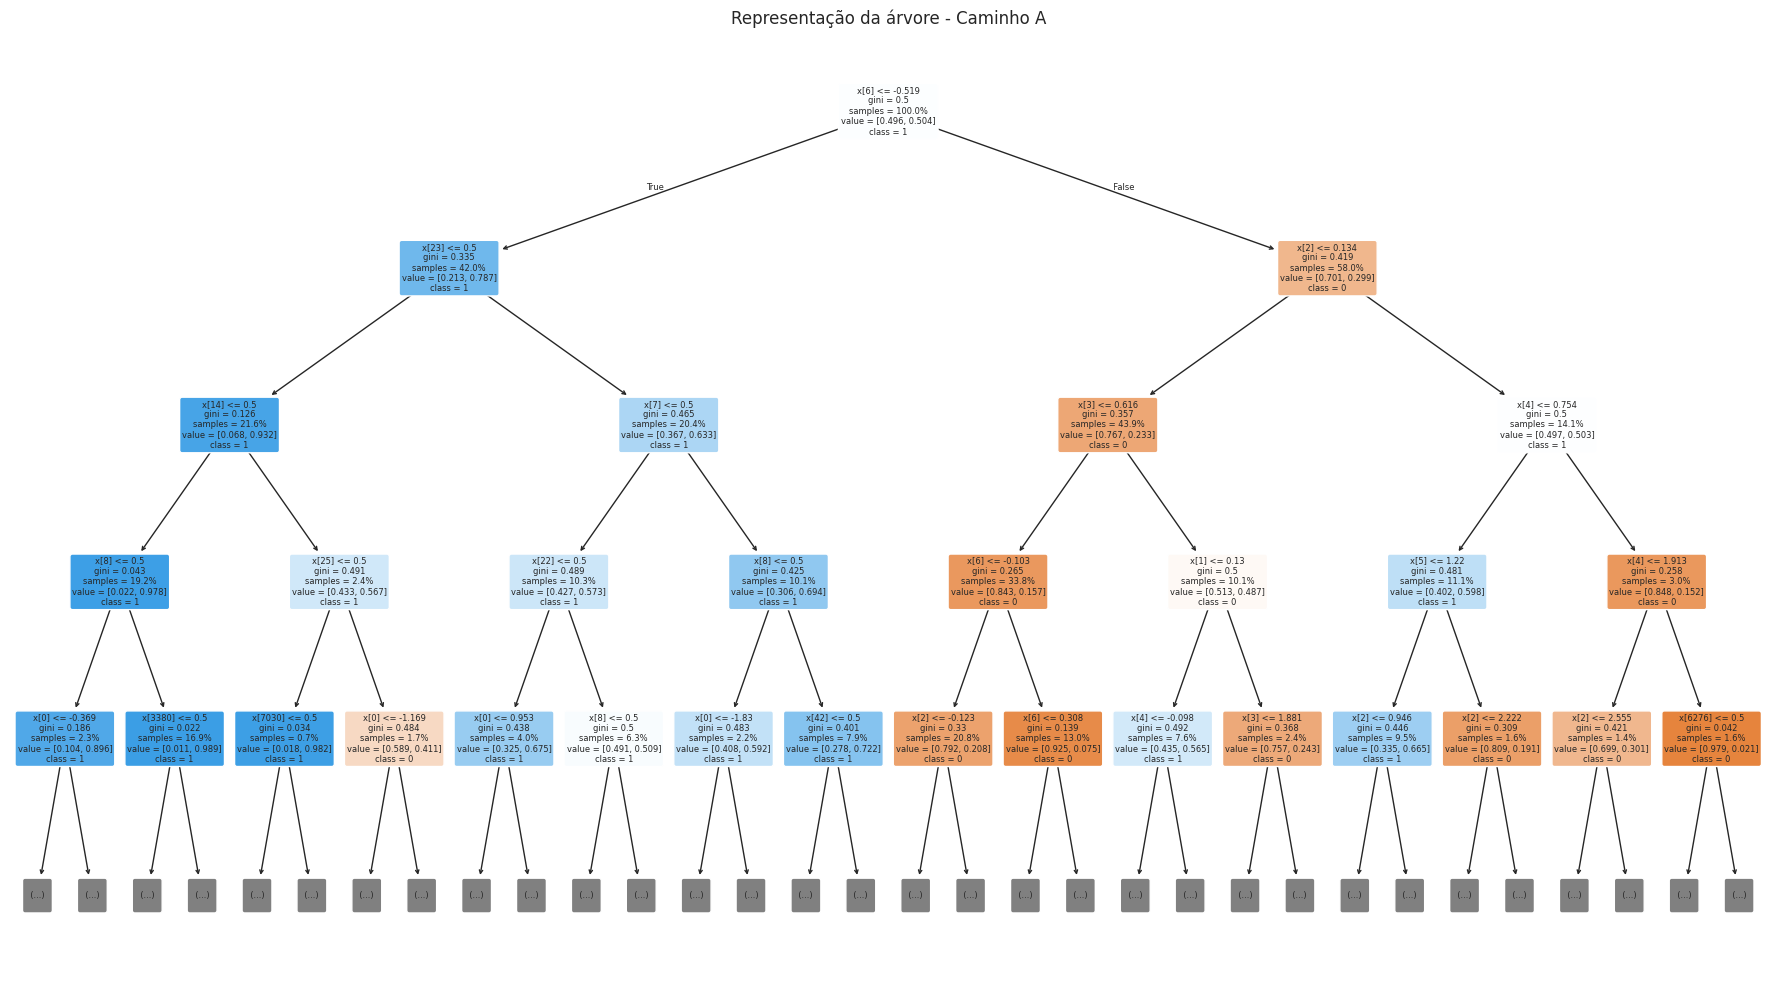

In [10]:
path_a_viz_pipeline = clone(path_a_pipeline)
path_a_viz_pipeline.fit(X, y)

path_a_tree = path_a_viz_pipeline.named_steps["model"]

path_a_tree_fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    path_a_tree,
    max_depth=4,
    filled=True,
    rounded=True,
    proportion=True,
    class_names=["0", "1"],
    ax=ax,
    fontsize=6,
)
ax.set_title("Representação da árvore - Caminho A")
plt.tight_layout()

path_a_tree_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
path_a_tree_artifact = FIGURES_DIR / f"tree_path_a_{path_a_tree_timestamp}.svg"
path_a_tree_fig.savefig(path_a_tree_artifact, bbox_inches="tight")

print(f"Árvore do Caminho A salva em: {path_a_tree_artifact}")
plt.show()

### Avaliação

A avaliação do Caminho A usa validação cruzada estratificada com 10 folds. Em cada fold medimos acurácia, precisão, recall, F1, F1 por classe e ROC AUC. A curva ROC é construída a partir das predições out-of-fold, ou seja, cada ponto previsto vem de um modelo que não treinou naquele registro.

Ao final, treinamos novamente a pipeline em todo o conjunto de treino e salvamos modelo, histórico, métricas e ROC com o padrão de artefatos do projeto.


Artefatos salvos para Caminho A - Árvore de Decisão
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_a_20260605_092539.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_a_20260605_092539.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_a_20260605_092539.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_a_20260605_092539.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_a_20260605_092539.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_a,Caminho A - Árvore de Decisão,accuracy,0.7848,0.0204,0.7848
1,path_a,Caminho A - Árvore de Decisão,precision,0.7681,0.0171,0.7681
2,path_a,Caminho A - Árvore de Decisão,recall,0.8202,0.0292,0.8202
3,path_a,Caminho A - Árvore de Decisão,f1,0.7932,0.0211,0.7933
4,path_a,Caminho A - Árvore de Decisão,f1_class_0,0.7755,0.0200,0.7755
5,path_a,Caminho A - Árvore de Decisão,f1_class_1,0.7932,0.0211,0.7933
6,path_a,Caminho A - Árvore de Decisão,roc_auc,0.8681,0.0164,0.8674


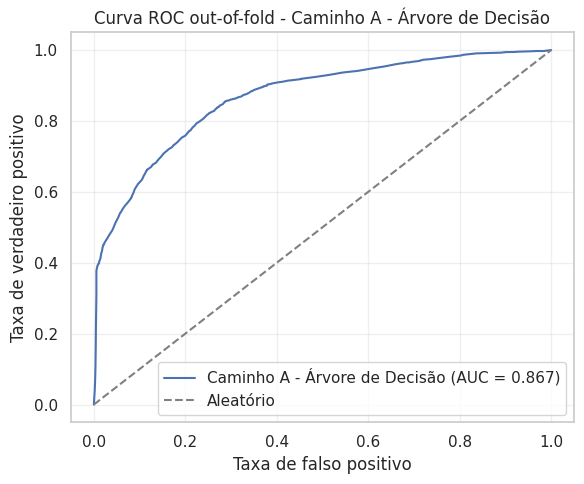

In [11]:
# Avaliação e salvamento do Caminho A - Árvore de Decisão
experiment_id = "path_a"
experiment_label = "Caminho A - Árvore de Decisão"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_a_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_a_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_a_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_a_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_a_oof_pred.iloc[valid_idx] = fold_pred
    path_a_oof_score.iloc[valid_idx] = fold_score

    path_a_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_a_history = pd.DataFrame(path_a_history_rows)
path_a_oof_metrics = classification_metrics(
    y_cv,
    path_a_oof_pred.astype(int),
    path_a_oof_score.astype(float),
)

path_a_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_a_history[metric].mean(),
            "cv_std": path_a_history[metric].std(ddof=0),
            "out_of_fold": path_a_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_a_oof_score.astype(float))
path_a_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_a_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_a_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_a_final_pipeline = clone(path_a_pipeline)
path_a_final_pipeline.fit(X_cv, y_cv)

path_a_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_a_final_pipeline,
    history_df=path_a_history,
    metrics_df=path_a_metrics,
    roc_df=path_a_roc,
    roc_fig=path_a_fig,
    artifact_files=path_a_artifacts,
    best_params=best_params,
)

path_a_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_a_final_pipeline,
    "history": path_a_history,
    "metrics": path_a_metrics,
    "roc": path_a_roc,
    "artifact_files": path_a_artifacts,
    "oof_pred": path_a_oof_pred.astype(int),
    "oof_score": path_a_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_a_artifacts[key]}")

display(path_a_metrics.round(4))
plt.show()


## Floresta Aleatória

Uma floresta aleatória combina várias árvores de decisão treinadas com amostras e subconjuntos de atributos diferentes. Cada árvore vota em uma classe, e o conjunto tende a ser mais estável do que uma árvore única.

A vantagem principal é reduzir variância e melhorar generalização. O custo é menor interpretabilidade e mais tempo de treinamento.


### Treinamento

Caminho B usa `RandomForestClassifier` com `n_estimators=200`, ou seja, 200 árvores no conjunto. Mantemos `random_state=42` para reprodutibilidade e `n_jobs=-1` para permitir paralelização interna do modelo.

A pipeline de entrada é a mesma do Caminho A: pré-processamento compartilhado seguido do classificador.


In [12]:
experiment_id = "path_b"
params_path = MODELS_DIR / f"params_{experiment_id}.json"

# Carrega parâmetros se o artefato existir, ou roda o Optuna
if params_path.exists():
    with open(params_path, "r") as f:
        best_params = json.load(f)
else:
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
        }
        # Instancia o modelo com os parâmetros sugeridos
        model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
        pipeline = make_model_pipeline(model)
        
        # Avalia e retorna a métrica alvo
        return cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)
    best_params = study.best_params
    print("Melhores parâmetros encontrados pelo Optuna:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

# Constrói a pipeline final usando os melhores parâmetros (desempacotando o dicionário)
final_model = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
path_b_pipeline = make_model_pipeline(final_model)

print("Pipeline do caminho B")
path_b_pipeline

Pipeline do caminho B


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'


Árvore do Caminho B salva em: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/tree_path_b_20260605_092544.svg


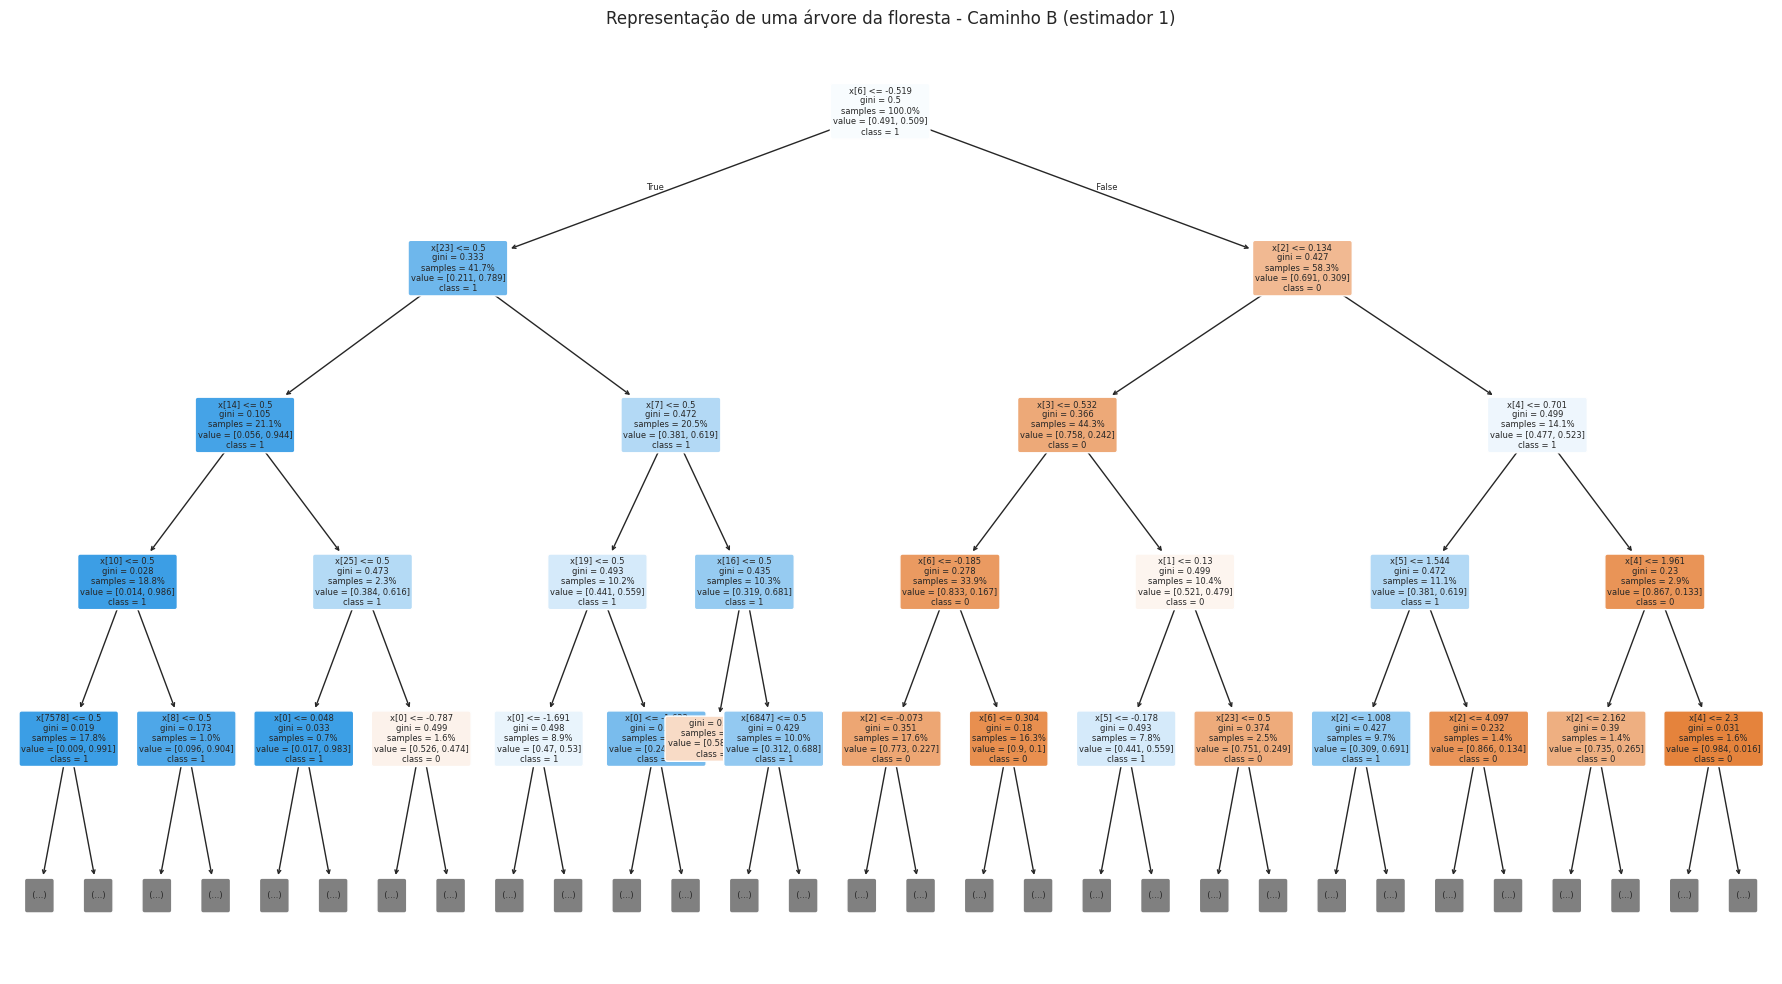

In [13]:
path_b_viz_pipeline = clone(path_b_pipeline)
path_b_viz_pipeline.fit(X, y)

path_b_forest = path_b_viz_pipeline.named_steps["model"]
path_b_tree_index = 0
path_b_tree = path_b_forest.estimators_[path_b_tree_index]

path_b_tree_fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    path_b_tree,
    max_depth=4,
    filled=True,
    rounded=True,
    proportion=True,
    class_names=["0", "1"],
    ax=ax,
    fontsize=6,
)
ax.set_title(
    f"Representação de uma árvore da floresta - Caminho B (estimador {path_b_tree_index + 1})" # Apenas uma das 200 árvores
)
plt.tight_layout()

path_b_tree_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
path_b_tree_artifact = FIGURES_DIR / f"tree_path_b_{path_b_tree_timestamp}.svg"
path_b_tree_fig.savefig(path_b_tree_artifact, bbox_inches="tight")

print(f"Árvore do Caminho B salva em: {path_b_tree_artifact}")
plt.show()

### Avaliação

O Caminho B é avaliado com o mesmo procedimento do Caminho A. Isso mantém a comparação justa: mesmos folds, mesmas métricas, mesma forma de gerar a curva ROC out-of-fold e mesma rotina de salvamento de artefatos.


Artefatos salvos para Caminho B - Floresta Aleatória
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_b_20260605_092636.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_b_20260605_092636.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_b_20260605_092636.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_b_20260605_092636.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_b_20260605_092636.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_b,Caminho B - Floresta Aleatória,accuracy,0.7988,0.0147,0.7988
1,path_b,Caminho B - Floresta Aleatória,precision,0.8067,0.0122,0.8068
2,path_b,Caminho B - Floresta Aleatória,recall,0.7896,0.0243,0.7896
3,path_b,Caminho B - Floresta Aleatória,f1,0.7980,0.0167,0.7981
4,path_b,Caminho B - Floresta Aleatória,f1_class_0,0.7996,0.0132,0.7995
5,path_b,Caminho B - Floresta Aleatória,f1_class_1,0.7980,0.0167,0.7981
6,path_b,Caminho B - Floresta Aleatória,roc_auc,0.8869,0.0132,0.8866


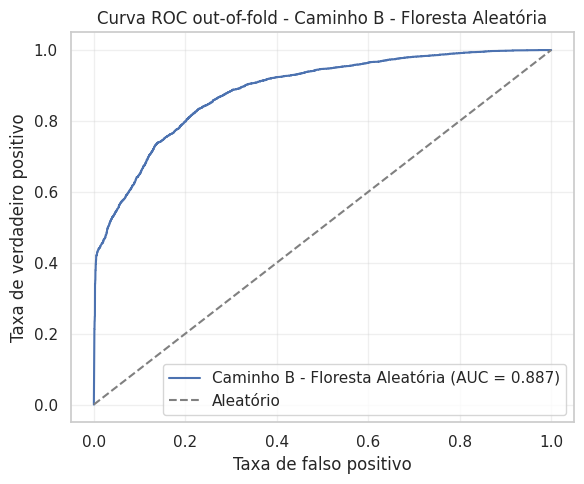

In [14]:
# Avaliação e salvamento do Caminho B - Floresta Aleatória
experiment_id = "path_b"
experiment_label = "Caminho B - Floresta Aleatória"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_b_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_b_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_b_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_b_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_b_oof_pred.iloc[valid_idx] = fold_pred
    path_b_oof_score.iloc[valid_idx] = fold_score

    path_b_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_b_history = pd.DataFrame(path_b_history_rows)
path_b_oof_metrics = classification_metrics(
    y_cv,
    path_b_oof_pred.astype(int),
    path_b_oof_score.astype(float),
)

path_b_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_b_history[metric].mean(),
            "cv_std": path_b_history[metric].std(ddof=0),
            "out_of_fold": path_b_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_b_oof_score.astype(float))
path_b_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_b_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_b_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_b_final_pipeline = clone(path_b_pipeline)
path_b_final_pipeline.fit(X_cv, y_cv)

path_b_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_b_final_pipeline,
    history_df=path_b_history,
    metrics_df=path_b_metrics,
    roc_df=path_b_roc,
    roc_fig=path_b_fig,
    artifact_files=path_b_artifacts,
    best_params=best_params,
)

path_b_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_b_final_pipeline,
    "history": path_b_history,
    "metrics": path_b_metrics,
    "roc": path_b_roc,
    "artifact_files": path_b_artifacts,
    "oof_pred": path_b_oof_pred.astype(int),
    "oof_score": path_b_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_b_artifacts[key]}")

display(path_b_metrics.round(4))
plt.show()


## Naive Bayes Gaussiano

O Caminho C usa `GaussianNB`, um modelo probabilístico que estima, para cada classe, uma distribuição normal por atributo numérico transformado. Ele é simples, rápido e serve como um contraste útil com os modelos baseados em árvores dos Caminhos A e B.


### Pipeline de pré-processamento

A próxima célula cria uma variação mínima da pipeline original apenas para o `GaussianNB`. Mantemos a mesma engenharia de atributos, as mesmas imputações, o `StandardScaler` das variáveis numéricas e a mesma codificação das variáveis binárias e categóricas.

A diferença necessária está no `OneHotEncoder`: na pipeline compartilhada ele gera saída esparsa, adequada para economizar memória em árvore de decisão e floresta aleatória. O `GaussianNB`, porém, espera uma matriz densa para estimar médias e variâncias de cada atributo por classe. Por isso, esta versão altera somente `sparse_output=False` no one-hot e fica restrita ao Caminho C.


In [15]:
gaussian_nb_preprocessing_pipeline = clone(preprocessing_pipeline).set_params(
    columns__cat__encoder__sparse_output=False,
)

print("Pipeline de pré-processamento alternativa para GaussianNB")
gaussian_nb_preprocessing_pipeline


Pipeline de pré-processamento alternativa para GaussianNB


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'
,spend_columns,"['RoomService', 'FoodCourt', ...]"
,total_col,'TotalSpend'
,n_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"


### Treinamento

Caminho C usa `GaussianNB`. Diferente das árvores, ele não aprende divisões ou conjuntos de árvores: ele estima a probabilidade de cada classe a partir das distribuições dos atributos já transformados. A pipeline completa usa o pré-processamento alternativo definido acima e depois o classificador gaussiano.


In [16]:
experiment_id = "path_c"
params_path = MODELS_DIR / f"params_{experiment_id}.json"

# Carrega parâmetros se o artefato existir, ou roda o Optuna
if params_path.exists():
    with open(params_path, "r") as f:
        best_params = json.load(f)
else:
    def objective(trial):
        params = {
            "var_smoothing": trial.suggest_float("var_smoothing", 1e-9, 1e-3, log=True)
        }
        # Instancia o modelo com os parâmetros sugeridos
        model = GaussianNB(**params)
        pipeline = Pipeline(
            steps=[
                ("preprocess", clone(gaussian_nb_preprocessing_pipeline)),
                ("model", model),
            ]
        )
        
        # Avalia e retorna a métrica alvo
        return cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)
    best_params = study.best_params
    
    print("Melhores parâmetros encontrados pelo Optuna:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

# Constrói a pipeline final usando os melhores parâmetros (desempacotando o dicionário)
final_model = GaussianNB(**best_params)
pipeline = Pipeline(
    steps=[
        ("preprocess", clone(gaussian_nb_preprocessing_pipeline)),
        ("model", final_model),
    ]
)
path_c_pipeline = pipeline

print("Pipeline do caminho C")
path_c_pipeline

[I 2026-06-05 09:26:37,067] A new study created in memory with name: no-name-be7b7546-75a4-4770-b76f-10dfc22fdead
[I 2026-06-05 09:26:58,970] Trial 0 finished with value: 0.5244450279728359 and parameters: {'var_smoothing': 4.178560590833027e-08}. Best is trial 0 with value: 0.5244450279728359.
[I 2026-06-05 09:27:15,368] Trial 1 finished with value: 0.5714223965281666 and parameters: {'var_smoothing': 0.0005866714266737888}. Best is trial 1 with value: 0.5714223965281666.
[I 2026-06-05 09:27:26,238] Trial 2 finished with value: 0.5309418682669692 and parameters: {'var_smoothing': 4.478808212323461e-06}. Best is trial 1 with value: 0.5714223965281666.
[I 2026-06-05 09:27:37,709] Trial 3 finished with value: 0.5250729708918358 and parameters: {'var_smoothing': 3.0402226857453434e-09}. Best is trial 1 with value: 0.5714223965281666.
[I 2026-06-05 09:27:49,413] Trial 4 finished with value: 0.5245808431260343 and parameters: {'var_smoothing': 1.8773522532495835e-08}. Best is trial 1 with v

Melhores parâmetros encontrados pelo Optuna:
  var_smoothing: 0.0009815405019274585
Pipeline do caminho C


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'


### Avaliação

O Caminho C é avaliado com o mesmo procedimento dos Caminhos A e B: validação cruzada estratificada com 10 folds, métricas out-of-fold, curva ROC out-of-fold e salvamento dos mesmos artefatos. Assim, a comparação no benchmarking continua justa, mudando apenas o modelo e a adaptação técnica necessária para o `GaussianNB`.


Artefatos salvos para Caminho C - Naive Bayes Gaussiano
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_c_20260605_093303.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_c_20260605_093303.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_c_20260605_093303.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_c_20260605_093303.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_c_20260605_093303.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_c,Caminho C - Naive Bayes Gaussiano,accuracy,0.5809,0.0143,0.5809
1,path_c,Caminho C - Naive Bayes Gaussiano,precision,0.5804,0.0144,0.5802
2,path_c,Caminho C - Naive Bayes Gaussiano,recall,0.6071,0.0247,0.6071
3,path_c,Caminho C - Naive Bayes Gaussiano,f1,0.5932,0.0157,0.5934
4,path_c,Caminho C - Naive Bayes Gaussiano,f1_class_0,0.5675,0.0183,0.5677
5,path_c,Caminho C - Naive Bayes Gaussiano,f1_class_1,0.5932,0.0157,0.5934
6,path_c,Caminho C - Naive Bayes Gaussiano,roc_auc,0.5878,0.0137,0.5876


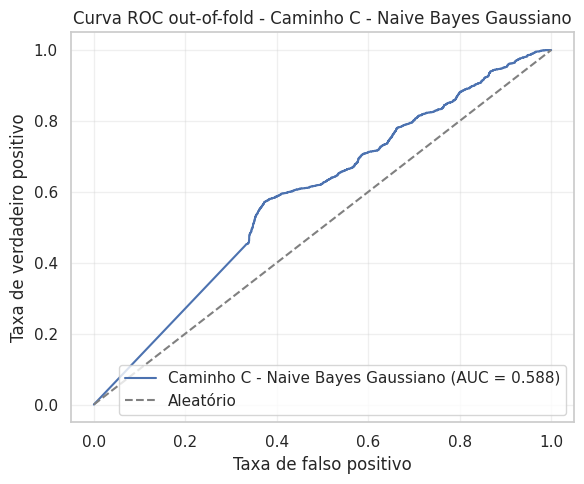

In [17]:
# Avaliação e salvamento do Caminho C - Naive Bayes Gaussiano
experiment_id = "path_c"
experiment_label = "Caminho C - Naive Bayes Gaussiano"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_c_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_c_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_c_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_c_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_c_oof_pred.iloc[valid_idx] = fold_pred
    path_c_oof_score.iloc[valid_idx] = fold_score

    path_c_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_c_history = pd.DataFrame(path_c_history_rows)
path_c_oof_metrics = classification_metrics(
    y_cv,
    path_c_oof_pred.astype(int),
    path_c_oof_score.astype(float),
)

path_c_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_c_history[metric].mean(),
            "cv_std": path_c_history[metric].std(ddof=0),
            "out_of_fold": path_c_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_c_oof_score.astype(float))
path_c_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_c_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_c_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_c_final_pipeline = clone(path_c_pipeline)
path_c_final_pipeline.fit(X_cv, y_cv)

path_c_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_c_final_pipeline,
    history_df=path_c_history,
    metrics_df=path_c_metrics,
    roc_df=path_c_roc,
    roc_fig=path_c_fig,
    artifact_files=path_c_artifacts,
    best_params=best_params,
)

path_c_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_c_final_pipeline,
    "history": path_c_history,
    "metrics": path_c_metrics,
    "roc": path_c_roc,
    "artifact_files": path_c_artifacts,
    "oof_pred": path_c_oof_pred.astype(int),
    "oof_score": path_c_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_c_artifacts[key]}")

display(path_c_metrics.round(4))
plt.show()


## Benchmarking

Nesta avaliação geral, reunimos as métricas out-of-fold dos três experimentos e criamos um ranking. O F1 é usado como critério principal porque combina precisão e recall; em caso de empate, olhamos ROC AUC e acurácia.


In [18]:
def benchmark_row(result):
    """Transforma a tabela de métricas de um experimento em uma linha para ranking."""
    metrics = result["metrics"].set_index("metric")["out_of_fold"].to_dict()
    return {
        "experiment_id": result["experiment_id"],
        "experiment_label": result["experiment_label"],
        **metrics,
        "model_artifact": result["artifact_files"]["model"],
        "metrics_artifact": result["artifact_files"]["metrics"],
        "roc_artifact": result["artifact_files"]["roc_csv"],
    }


benchmark = pd.DataFrame(
    [benchmark_row(path_a_results), benchmark_row(path_b_results), benchmark_row(path_c_results)]
)
benchmark = benchmark.sort_values(
    by=["f1", "roc_auc", "accuracy"],
    ascending=False,
).reset_index(drop=True)

print("Ranking dos experimentos por F1, ROC AUC e acurácia")
display(
    benchmark[
        [
            "experiment_id",
            "experiment_label",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "f1_class_0",
            "f1_class_1",
            "roc_auc",
        ]
    ].round(4)
)

print("Artefatos principais por experimento")
display(benchmark[["experiment_id", "model_artifact", "metrics_artifact", "roc_artifact"]])


Ranking dos experimentos por F1, ROC AUC e acurácia


,experiment_id,experiment_label,accuracy,precision,recall,f1,f1_class_0,f1_class_1,roc_auc
0,path_b,Caminho B - Floresta Aleatória,0.7988,0.8068,0.7896,0.7981,0.7995,0.7981,0.8866
1,path_a,Caminho A - Árvore de Decisão,0.7848,0.7681,0.8202,0.7933,0.7755,0.7933,0.8674
2,path_c,Caminho C - Naive Bayes Gaussiano,0.5809,0.5802,0.6071,0.5934,0.5677,0.5934,0.5876


Artefatos principais por experimento


,experiment_id,model_artifact,metrics_artifact,roc_artifact
0,path_b,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...
1,path_a,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...
2,path_c,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...
